<a href="https://colab.research.google.com/github/lizbethQCC/2024/blob/main/Act8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# Estilo global profesional
sns.set_theme(style="whitegrid", context="talk")
mpl.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 280,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.labelweight': 'semibold',
    'legend.fontsize': 11,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
})

# Paleta consistente para clústeres
PALETTE = sns.color_palette("viridis", 10)

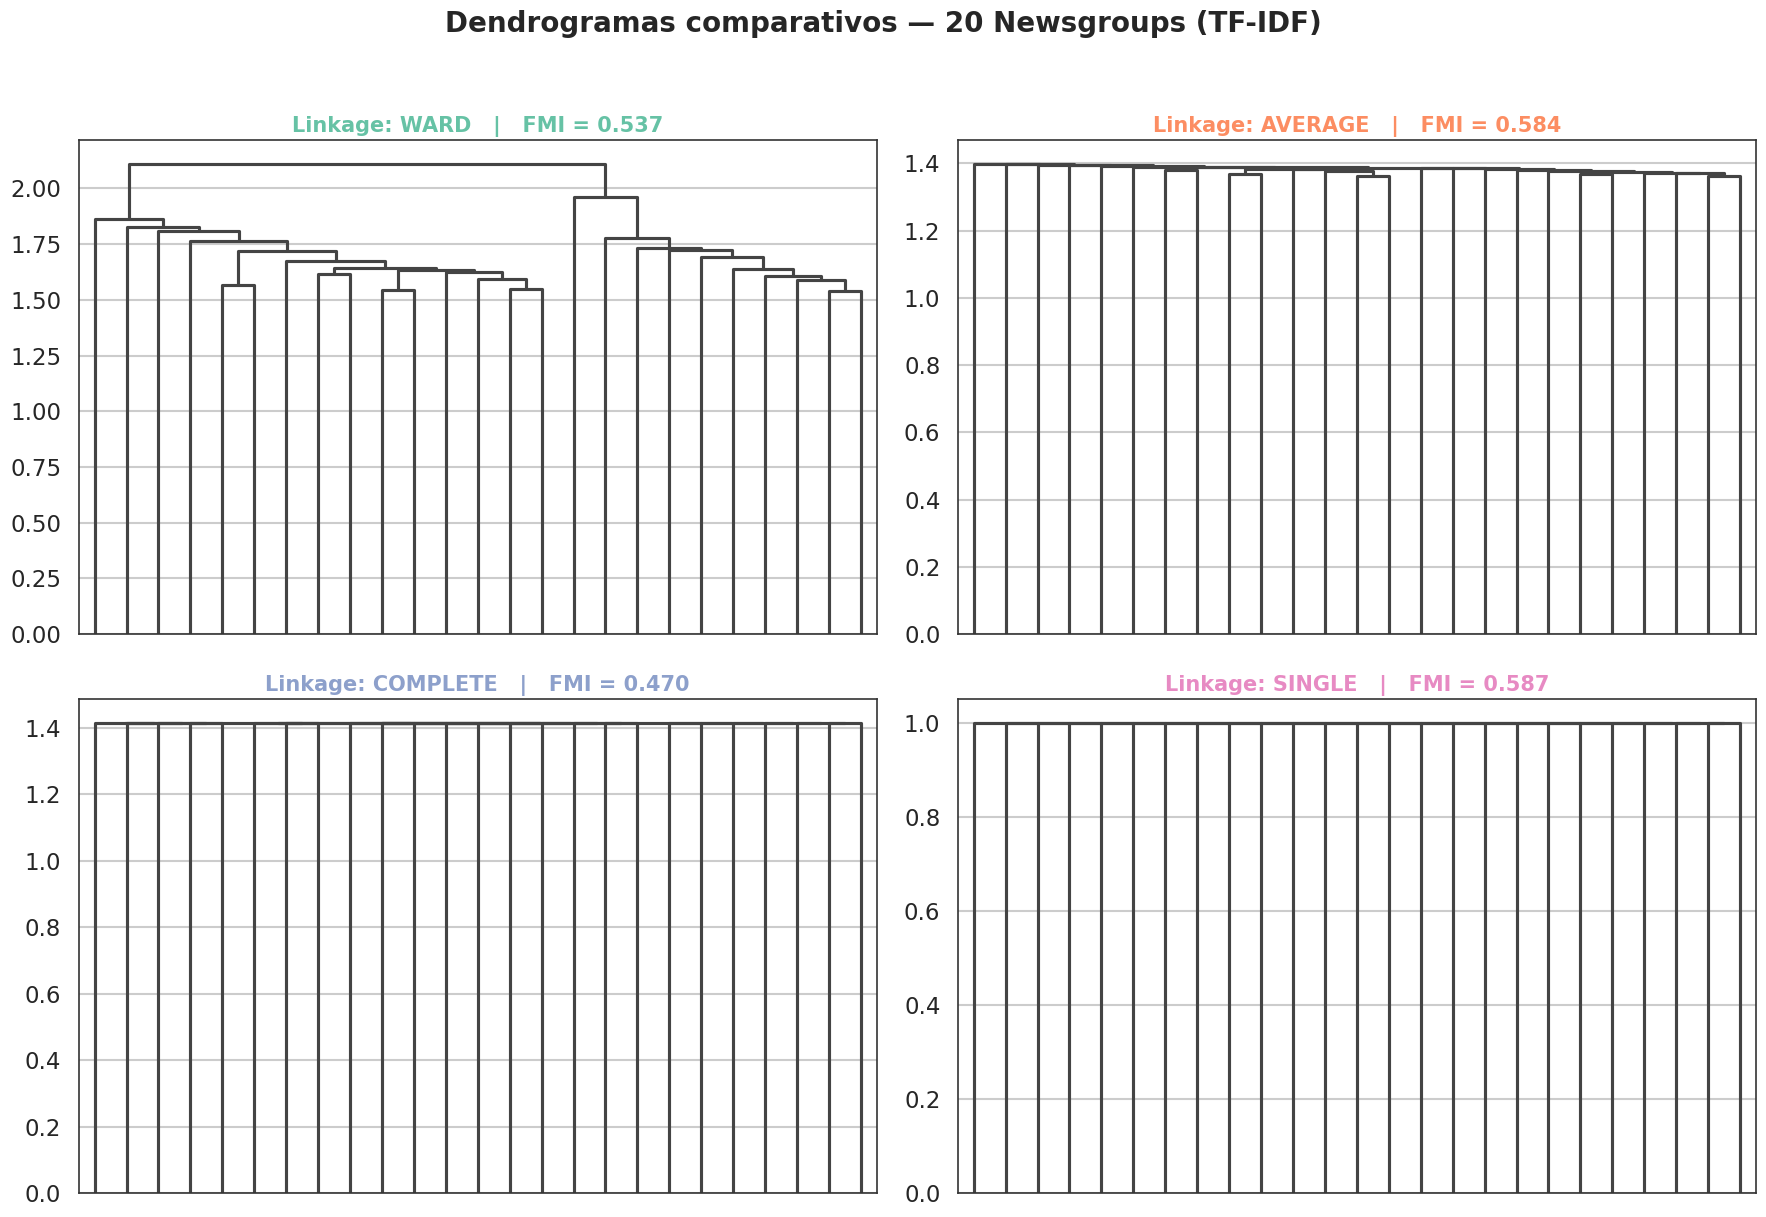

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import fowlkes_mallows_score
import matplotlib.pyplot as plt

# --- Carga de datos (subconjunto para viabilidad computacional) ---
categories = ['talk.religion.misc', 'sci.electronics', 'misc.forsale']
newsgroups = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))

vectorizer = TfidfVectorizer(max_features=800, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)

# Submuestra para dendrograma legible
np.random.seed(42)
idx = np.random.choice(X.shape[0], size=120, replace=False)
X_sub = X[idx].toarray()
y_sub = newsgroups.target[idx]

# --- Figura con 4 subplots (uno por linkage) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
linkages = ['ward', 'average', 'complete', 'single']
colors = sns.color_palette("Set2", 4)
scores = {}

for ax, method, color in zip(axes.ravel(), linkages, colors):
    Z = linkage(X_sub, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=25,
               color_threshold=0, above_threshold_color='#444444',
               no_labels=True, link_color_func=lambda k: '#444444')
    # Evaluar con FMI sobre el dataset completo
    Z_full = linkage(X.toarray(), method=method)
    labels = fcluster(Z_full, t=3, criterion='maxclust')
    fmi = fowlkes_mallows_score(newsgroups.target, labels)
    scores[method] = fmi
    ax.set_title(f"Linkage: {method.upper()}   |   FMI = {fmi:.3f}",
                 color=color, fontsize=15)

fig.suptitle("Dendrogramas comparativos — 20 Newsgroups (TF-IDF)",
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("text_dendrograms.png")
plt.show()

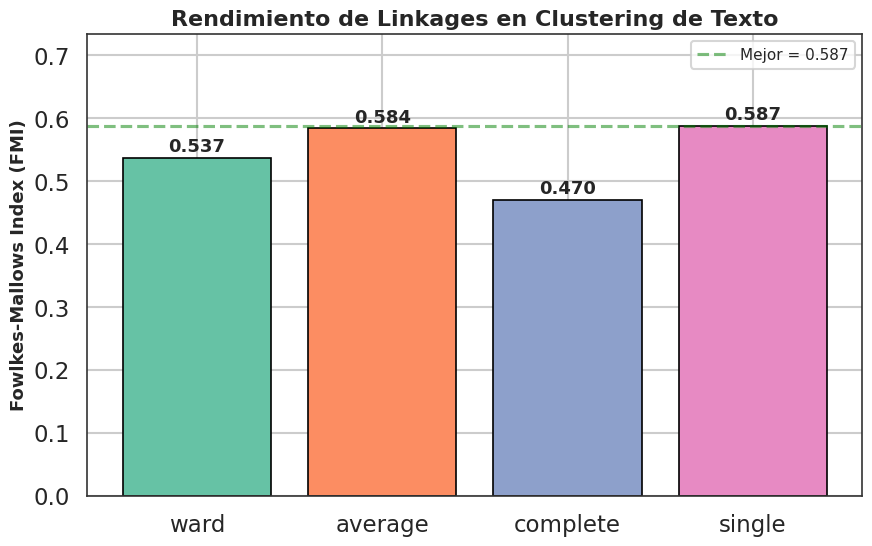

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
methods = list(scores.keys())
vals = [scores[m] for m in methods]
bars = ax.bar(methods, vals, color=sns.color_palette("Set2", 4),
              edgecolor='black', linewidth=1.2)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel("Fowlkes-Mallows Index (FMI)")
ax.set_title("Rendimiento de Linkages en Clustering de Texto")
ax.set_ylim(0, max(vals) * 1.25)
ax.axhline(max(vals), color='green', linestyle='--', alpha=0.5,
           label=f"Mejor = {max(vals):.3f}")
ax.legend()
plt.savefig("text_fmi.png")
plt.show()

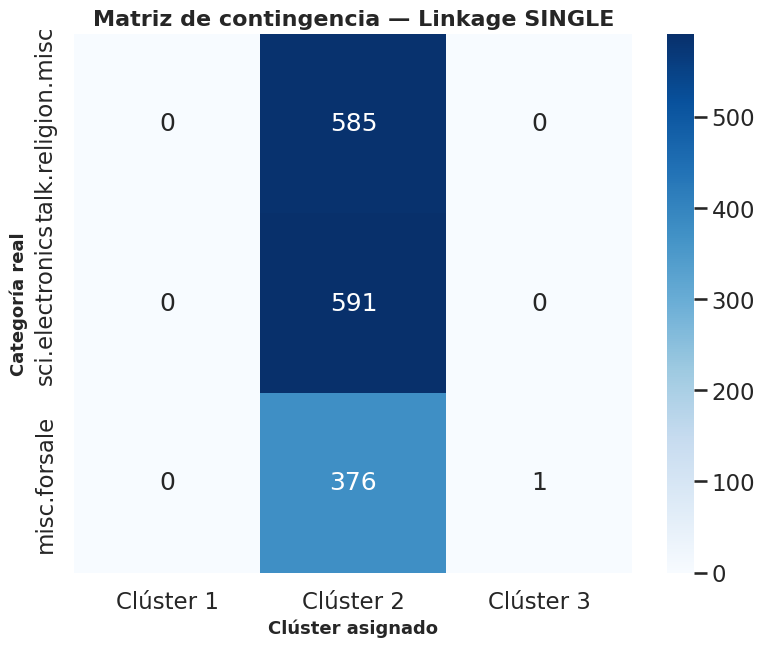

In [4]:
from sklearn.metrics import confusion_matrix

best_method = max(scores, key=scores.get)
Z_best = linkage(X.toarray(), method=best_method)
labels_best = fcluster(Z_best, t=3, criterion='maxclust')

cm = confusion_matrix(newsgroups.target, labels_best)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Clúster {i+1}" for i in range(cm.shape[1])],
            yticklabels=categories)
plt.title(f"Matriz de contingencia — Linkage {best_method.upper()}")
plt.ylabel("Categoría real")
plt.xlabel("Clúster asignado")
plt.savefig("text_confusion.png")
plt.show()

Clientes — Mall Customer Dataset

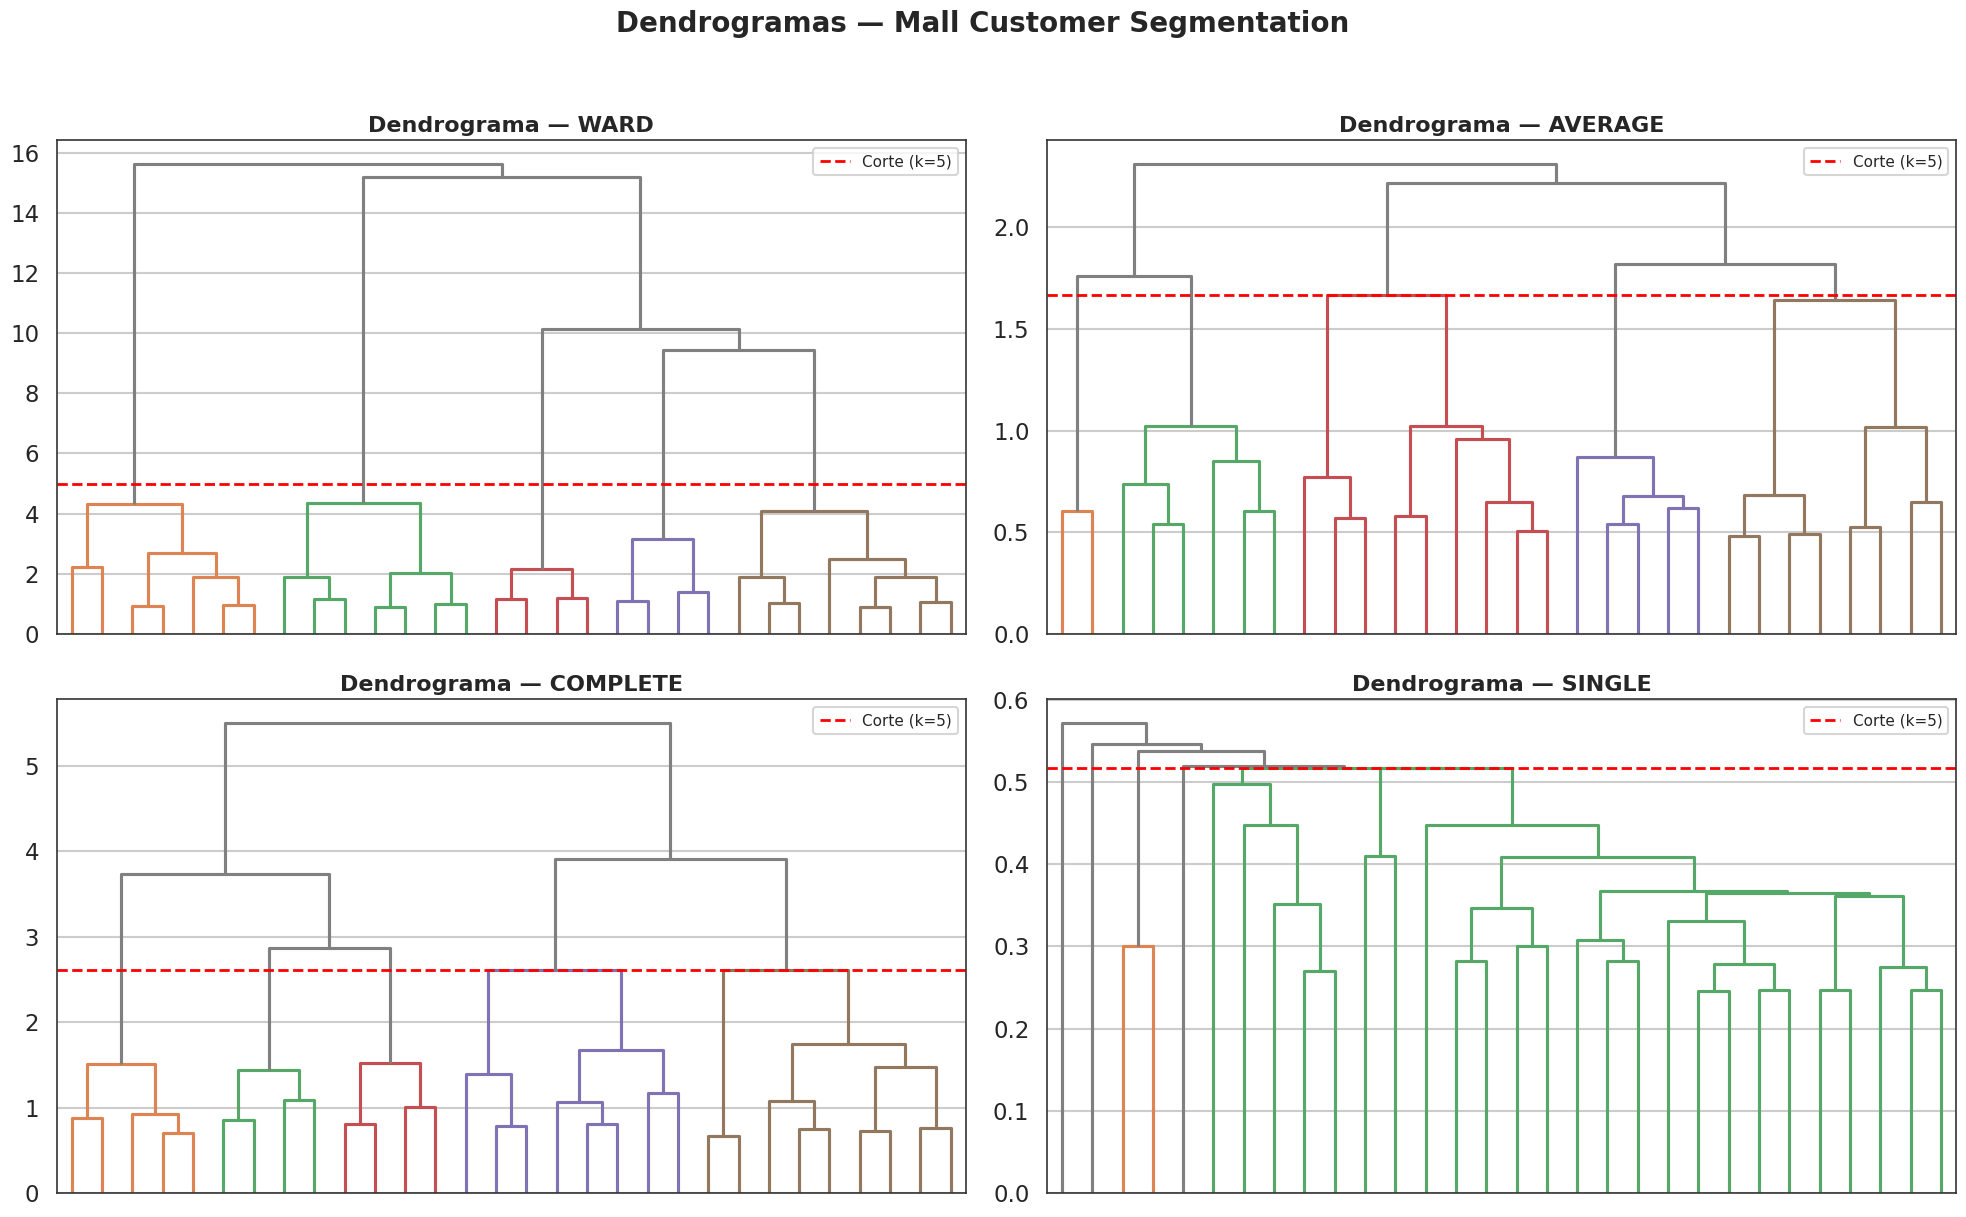

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

# Carga (ajusta la ruta si es necesario)
df = pd.read_csv('Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
linkages = ['ward', 'average', 'complete', 'single']

for ax, method in zip(axes.ravel(), linkages):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               color_threshold=Z[-4, 2] if method != 'ward' else 5,
               above_threshold_color='gray', no_labels=True)
    ax.axhline(y=Z[-5, 2] if method != 'ward' else 5,
               color='red', linestyle='--', linewidth=2,
               label='Corte (k=5)')
    ax.set_title(f"Dendrograma — {method.upper()}")
    ax.legend()

fig.suptitle("Dendrogramas — Mall Customer Segmentation",
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("mall_dendrograms.png")
plt.show()

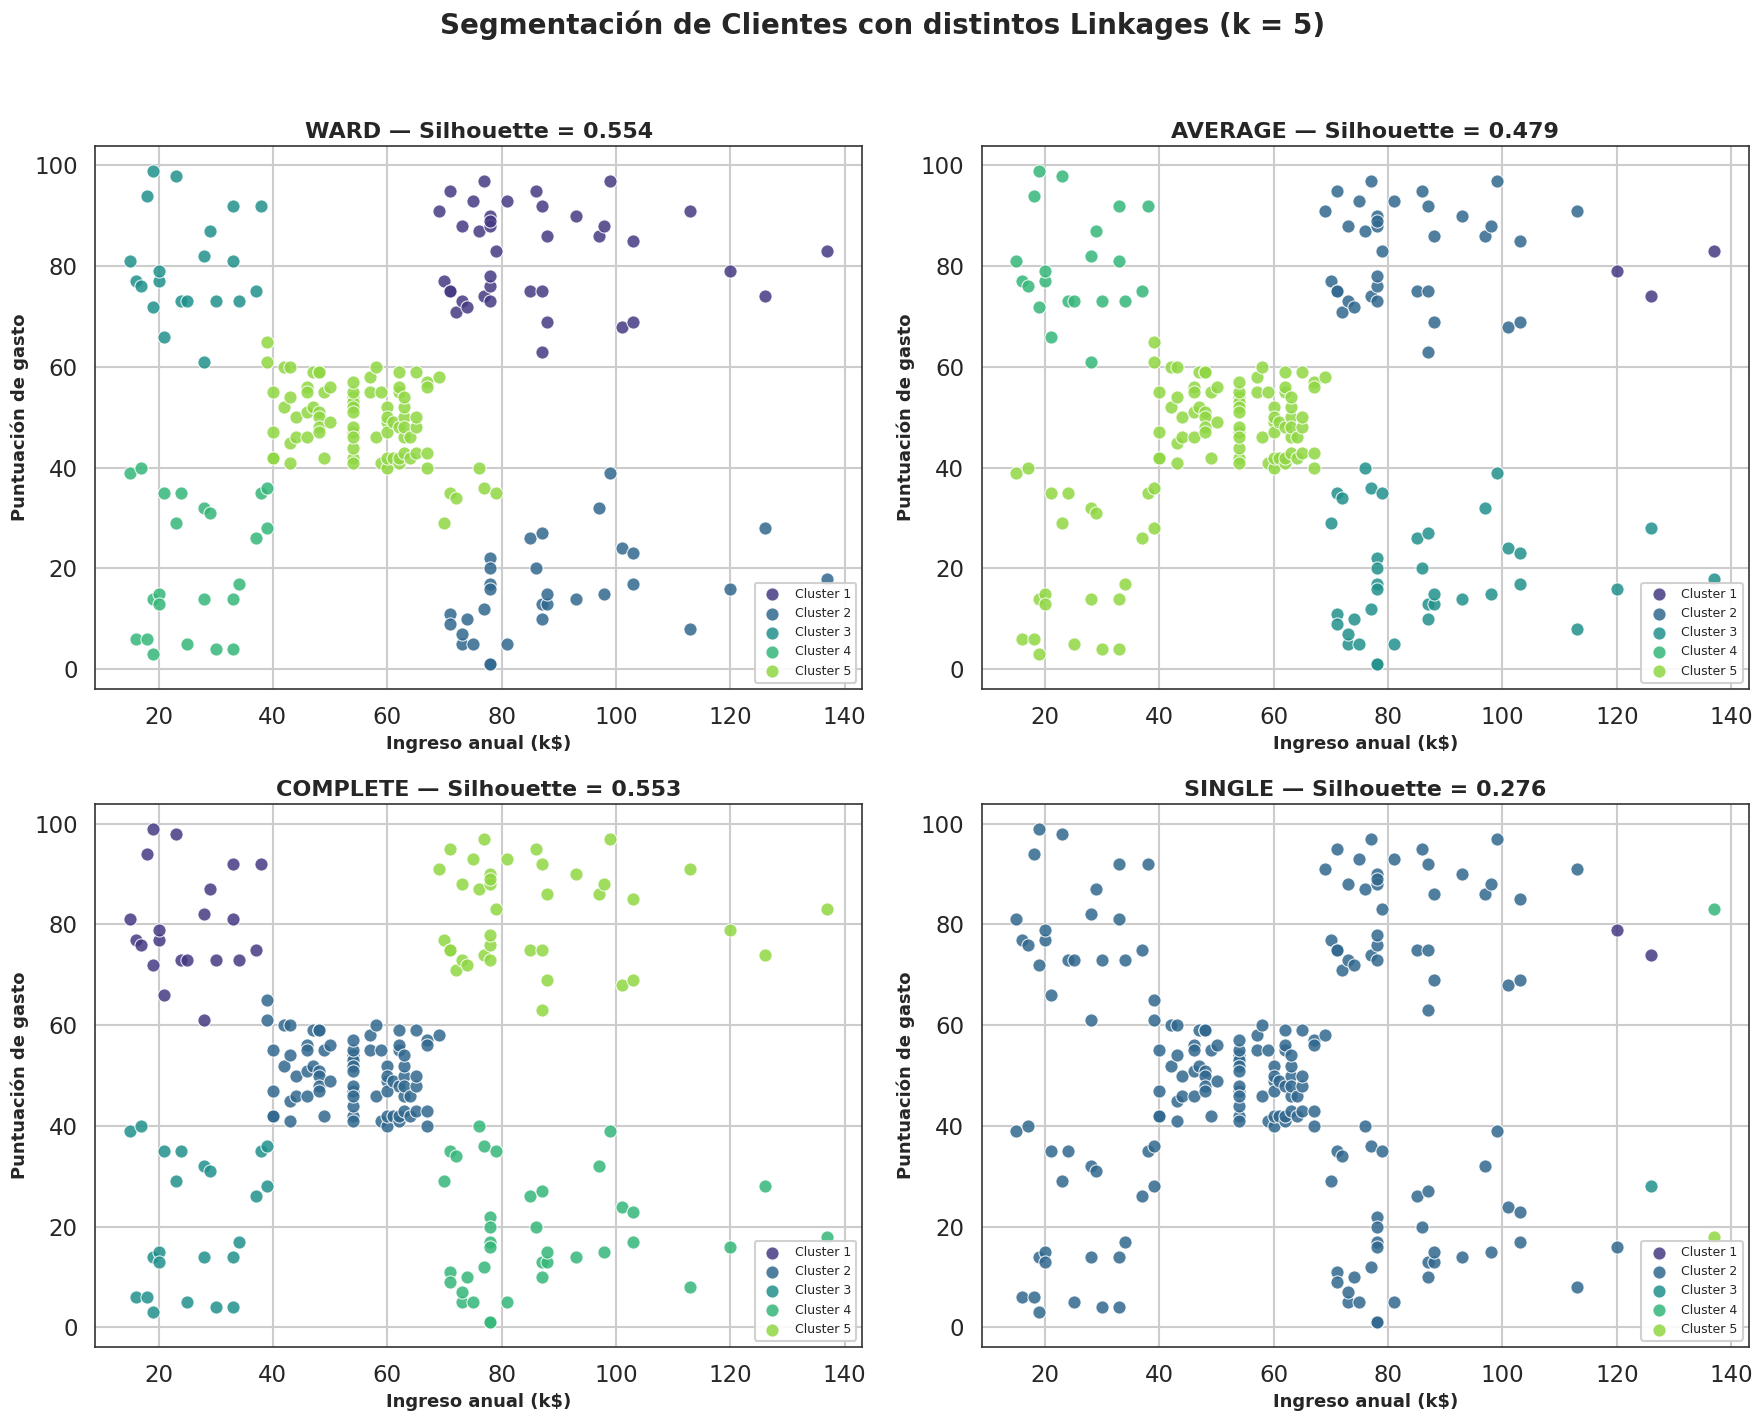

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, method in zip(axes.ravel(), linkages):
    Z = linkage(X_scaled, method=method)
    labels = fcluster(Z, t=5, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels)
    palette = sns.color_palette("viridis", len(np.unique(labels)))
    for i, c in enumerate(np.unique(labels)):
        mask = labels == c
        ax.scatter(X[mask, 0], X[mask, 1], s=90, alpha=0.85,
                   color=palette[i], edgecolor='white', linewidth=0.8,
                   label=f"Cluster {c}")
    ax.set_title(f"{method.upper()} — Silhouette = {sil:.3f}")
    ax.set_xlabel("Ingreso anual (k$)")
    ax.set_ylabel("Puntuación de gasto")
    ax.legend(loc='best', fontsize=9, framealpha=0.9)

fig.suptitle("Segmentación de Clientes con distintos Linkages (k = 5)",
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("mall_scatter.png")
plt.show()

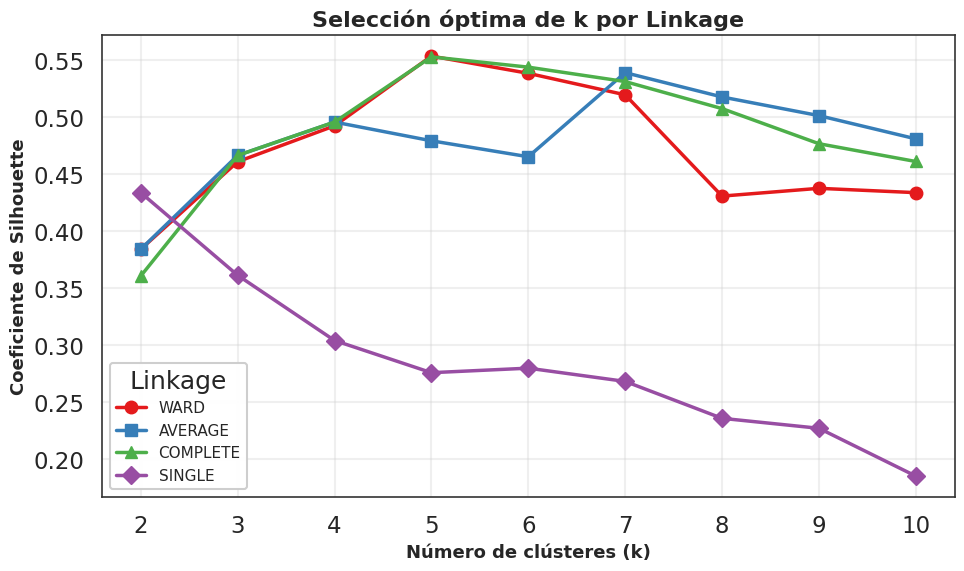

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
ks = range(2, 11)
markers = ['o', 's', '^', 'D']
colors = sns.color_palette("Set1", 4)

for method, marker, color in zip(linkages, markers, colors):
    Z = linkage(X_scaled, method=method)
    sil_scores = []
    for k in ks:
        labels = fcluster(Z, t=k, criterion='maxclust')
        sil_scores.append(silhouette_score(X_scaled, labels))
    ax.plot(ks, sil_scores, marker=marker, linewidth=2.5,
            markersize=9, color=color, label=method.upper())

ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Coeficiente de Silhouette")
ax.set_title("Selección óptima de k por Linkage")
ax.legend(title="Linkage", framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.savefig("mall_silhouette.png")
plt.show()

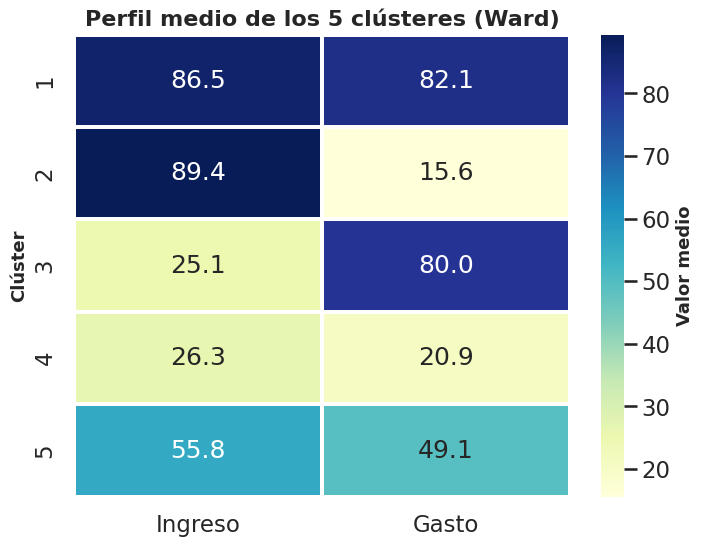

In [10]:
best_k = 5
Z = linkage(X_scaled, method='ward')
labels = fcluster(Z, t=best_k, criterion='maxclust')

profile = pd.DataFrame(X, columns=['Ingreso', 'Gasto'])
profile['Cluster'] = labels
summary = profile.groupby('Cluster').mean().round(1)

plt.figure(figsize=(8, 6))
sns.heatmap(summary, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Valor medio'}, linewidths=1.5)
plt.title(f"Perfil medio de los {best_k} clústeres (Ward)")
plt.ylabel("Clúster")
plt.savefig("mall_heatmap.png")
plt.show()

Imágenes — BSDS500

In [12]:
!unzip -q BSDS500.zip

In [13]:
!find /content -name "100075.jpg"

/content/BSDS500-master/BSDS500/data/images/train/100075.jpg


In [14]:
from skimage import io, color, segmentation
from skimage.segmentation import slic, mark_boundaries
from sklearn.cluster import AgglomerativeClustering

def segment_image(image, n_superpixels=250, n_clusters=8, linkage='ward'):
    segments = slic(image, n_segments=n_superpixels,
                    compactness=10, start_label=0)
    features = []
    for seg_id in np.unique(segments):
        mask = segments == seg_id
        color_mean = image[mask].mean(axis=0)
        ys, xs = np.where(mask)
        pos = [ys.mean() / image.shape[0], xs.mean() / image.shape[1]]
        features.append(np.concatenate([color_mean, pos * 0.5]))
    features = np.array(features)
    labels = AgglomerativeClustering(n_clusters=n_clusters,
                                     linkage=linkage).fit_predict(features)
    result = np.zeros(segments.shape, dtype=int)
    for i, sid in enumerate(np.unique(segments)):
        result[segments == sid] = labels[i]
    return segments, result

# Carga de imagen BSDS500 (ajusta la ruta)
#img = io.imread('BSDS500/images/train/100075.jpg')
#img = io.imread('BSDS500-master/BSDS500/data/images/train/100075.jpg')
img = io.imread('BSDS500-master/BSDS500/data/images/train/100075.jpg')

if img.shape[-1] == 4:
    img = color.rgba2rgb(img)
img = img / 255.0 if img.max() > 1 else img

In [18]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  # Lee la imagen directamente desde los bytes cargados
  img_bytes = uploaded[fn]
  img = io.imread(img_bytes, plugin='imageio')
  if img.shape[-1] == 4:
      img = color.rgba2rgb(img)
  img = img / 255.0 if img.max() > 1 else img
  print(f'Imagen "{fn}" cargada con éxito y lista para su procesamiento.')

Montaje comparativo: original + 4 linkages

✅ Imagen encontrada: /content/BSDS500-master/BSDS500/data/images/test/79073.jpg
✅ Imagen lista: shape=(321, 481, 3), dtype=float64, rango=[0.00, 1.00]


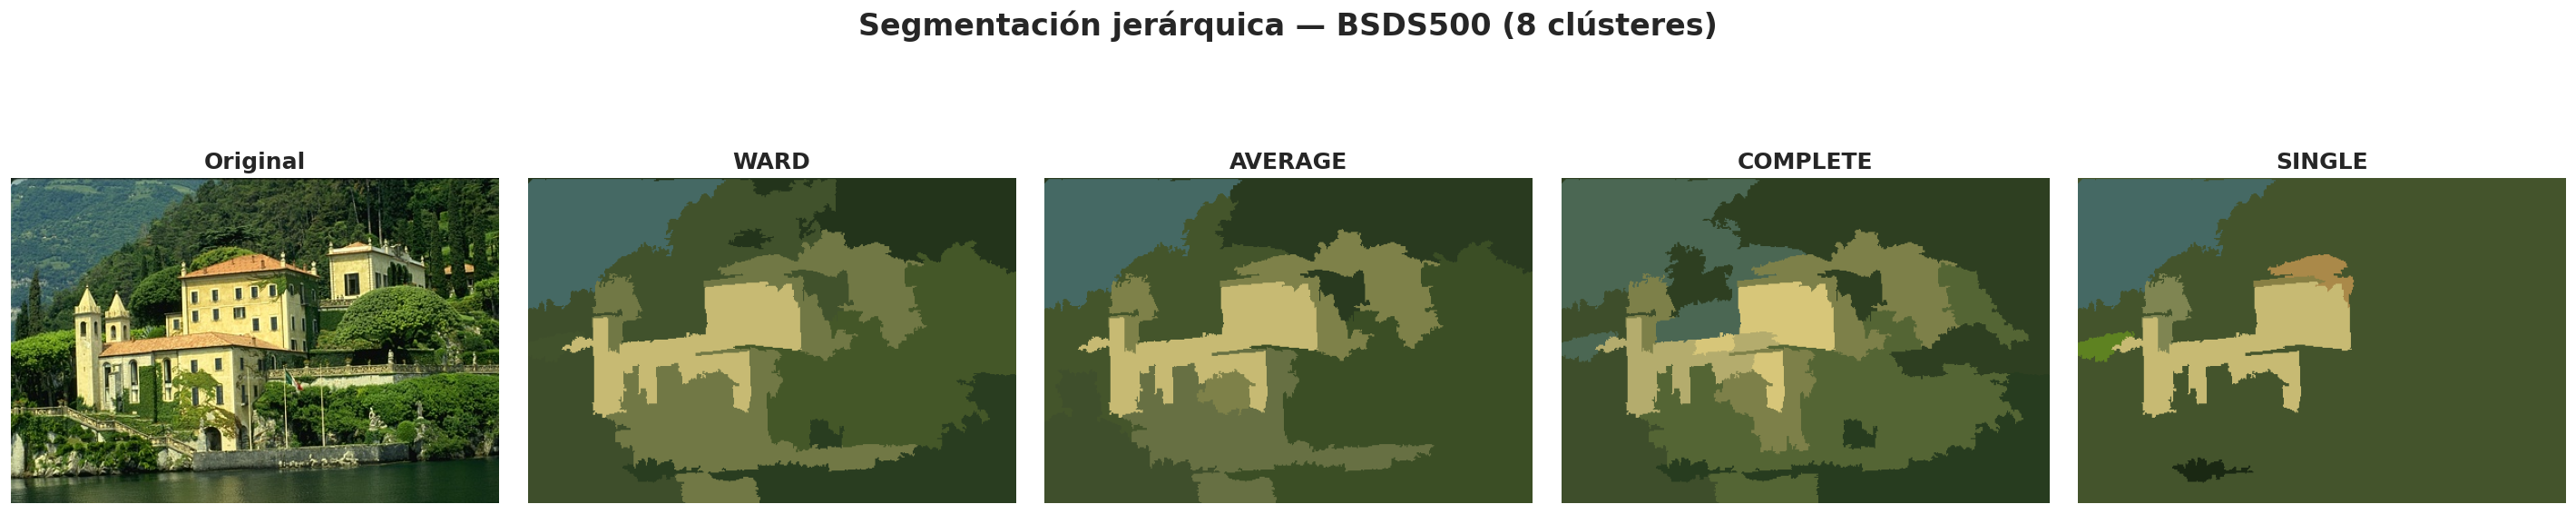

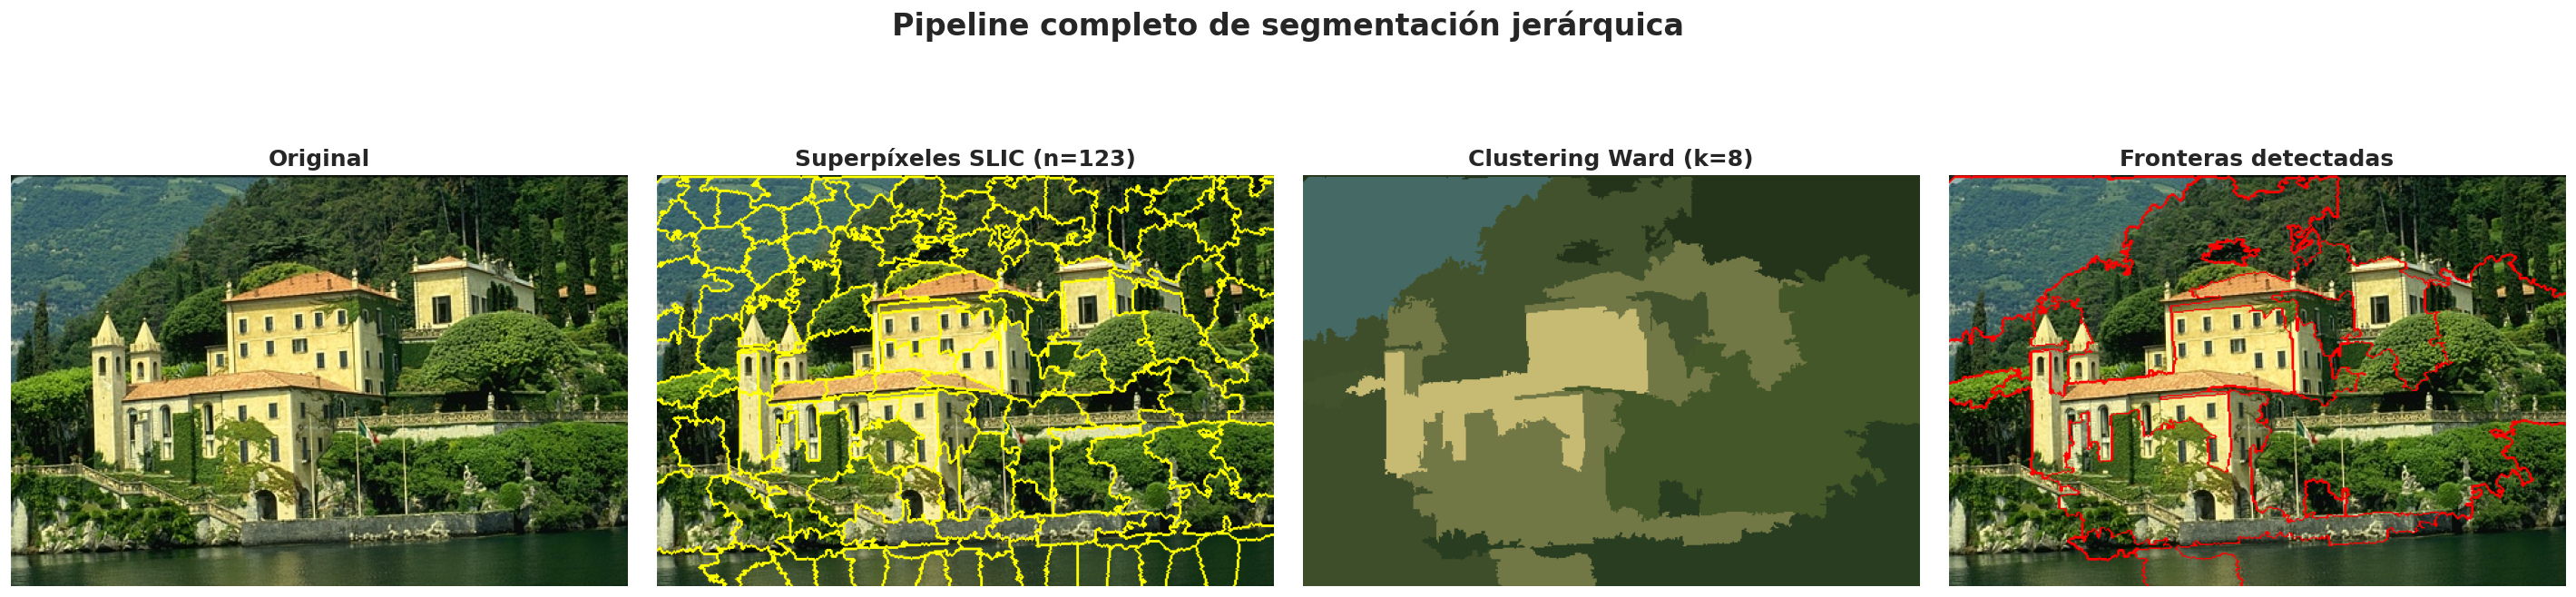

✅ Listo. Figuras guardadas: bsds_comparison.png, bsds_pipeline.png


In [19]:
# ============================================================
# CLUSTERING JERÁRQUICO PARA IMÁGENES — BSDS500 (una sola celda)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from skimage import io, color
from skimage.segmentation import slic
from sklearn.cluster import AgglomerativeClustering

# --- 1. Estilo global presentable ---
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.titlesize': 15, 'axes.titleweight': 'bold',
})

# --- 2. Localizar una imagen dentro del dataset ---
candidatos = list(Path('/content').rglob('*.jpg'))
if not candidatos:
    raise FileNotFoundError("No se encontraron imágenes .jpg. "
                            "Asegúrate de haber descomprimido BSDS500.zip")
ruta_img = candidatos[0]
print(f"✅ Imagen encontrada: {ruta_img}")

# --- 3. Cargar imagen y forzar RGB float [0,1] ---
img = io.imread(str(ruta_img))
if img.ndim == 2:
    img = color.gray2rgb(img)
elif img.shape[-1] == 4:
    img = color.rgba2rgb(img)
img = img.astype(np.float64)
if img.max() > 1.0:
    img = img / 255.0
print(f"✅ Imagen lista: shape={img.shape}, dtype={img.dtype}, "
      f"rango=[{img.min():.2f}, {img.max():.2f}]")

# --- 4. Función de segmentación jerárquica ---
def segment_image(image, n_superpixels=250, n_clusters=8, linkage='ward'):
    # Superpíxeles SLIC
    segments = slic(image, n_segments=n_superpixels,
                    compactness=10, start_label=0)

    # Características: color medio (3D) + posición normalizada (2D)
    features = []
    for seg_id in np.unique(segments):
        mask = segments == seg_id
        color_mean = np.asarray(image[mask].mean(axis=0),
                                dtype=np.float64).ravel()
        if color_mean.size == 1:
            color_mean = np.repeat(color_mean, 3)
        ys, xs = np.where(mask)
        pos = np.array([ys.mean() / image.shape[0],
                        xs.mean() / image.shape[1]], dtype=np.float64)
        features.append(np.concatenate([color_mean, pos * 0.5]))
    features = np.array(features, dtype=np.float64)

    # Clustering jerárquico
    labels = AgglomerativeClustering(
        n_clusters=n_clusters, linkage=linkage
    ).fit_predict(features)

    # Mapear etiquetas de vuelta a píxeles
    result = np.zeros(segments.shape, dtype=int)
    for i, sid in enumerate(np.unique(segments)):
        result[segments == sid] = labels[i]
    return segments, result

# --- 5. Comparar 4 linkages ---
linkages = ['ward', 'average', 'complete', 'single']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes[0].imshow(img)
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

for ax, method in zip(axes[1:], linkages):
    _, seg = segment_image(img, n_clusters=8, linkage=method)
    ax.imshow(color.label2rgb(seg, img, kind='avg', bg_label=-1))
    ax.set_title(f"{method.upper()}", fontweight='bold')
    ax.axis('off')

fig.suptitle("Segmentación jerárquica — BSDS500 (8 clústeres)",
             fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("bsds_comparison.png")
plt.show()

# --- 6. Pipeline detallado: SLIC → Ward → fronteras ---
segs, result = segment_image(img, n_superpixels=250,
                             n_clusters=8, linkage='ward')

from skimage.segmentation import mark_boundaries, find_boundaries
boundaries = find_boundaries(result, mode='outer')
overlay = img.copy()
overlay[boundaries] = [1, 0, 0]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(img)
axes[0].set_title("Original", fontweight='bold')

axes[1].imshow(mark_boundaries(img, segs, color=(1, 1, 0), mode='thick'))
axes[1].set_title(f"Superpíxeles SLIC (n={len(np.unique(segs))})",
                  fontweight='bold')

axes[2].imshow(color.label2rgb(result, img, kind='avg', bg_label=-1))
axes[2].set_title("Clustering Ward (k=8)", fontweight='bold')

axes[3].imshow(overlay)
axes[3].set_title("Fronteras detectadas", fontweight='bold')

for ax in axes:
    ax.axis('off')

fig.suptitle("Pipeline completo de segmentación jerárquica",
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("bsds_pipeline.png")
plt.show()

print("✅ Listo. Figuras guardadas: bsds_comparison.png, bsds_pipeline.png")

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Zoom en superpíxeles SLIC + resultado final

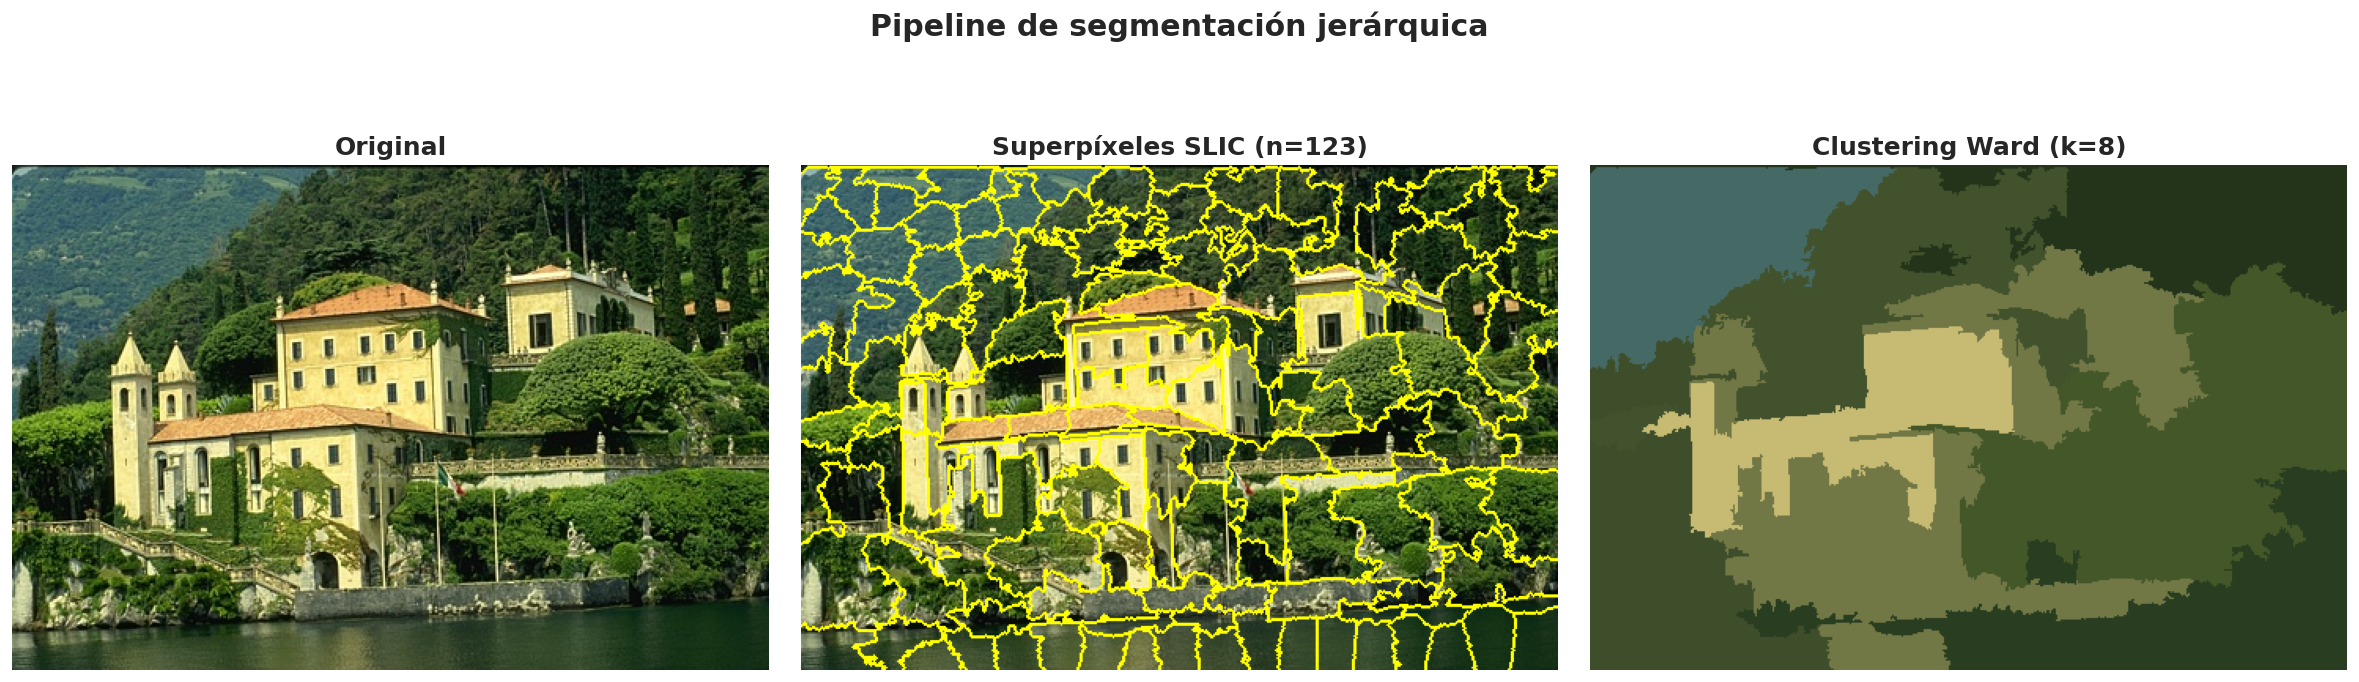

In [21]:
segs, result = segment_image(img, n_superpixels=250,
                             n_clusters=8, linkage='ward')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(img); axes[0].set_title("Original")
axes[1].imshow(mark_boundaries(img, segs, color=(1,1,0), mode='thick'))
axes[1].set_title(f"Superpíxeles SLIC (n={len(np.unique(segs))})")
axes[2].imshow(color.label2rgb(result, img, kind='avg', bg_label=-1))
axes[2].set_title("Clustering Ward (k=8)")

for ax in axes: ax.axis('off')
plt.suptitle("Pipeline de segmentación jerárquica", fontsize=18,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("bsds_pipeline.png")
plt.show()

Mapa de fronteras (boundary map) — Ward

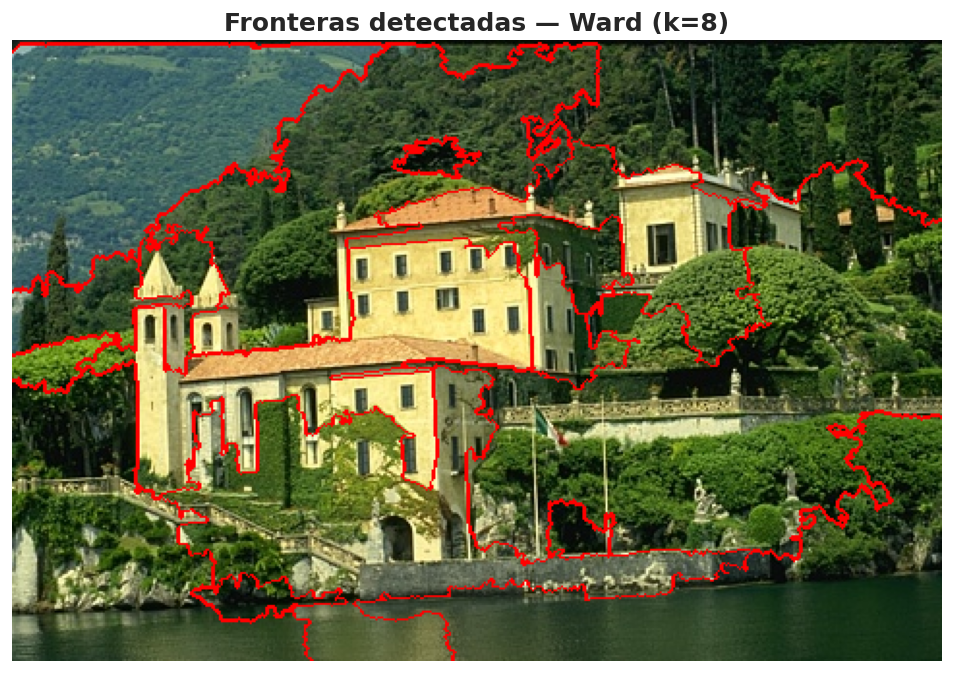

In [22]:
from skimage.segmentation import find_boundaries

boundaries = find_boundaries(result, mode='outer')
overlay = img.copy()
overlay[boundaries] = [1, 0, 0]  # rojo

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(overlay)
ax.set_title("Fronteras detectadas — Ward (k=8)", fontweight='bold')
ax.axis('off')
plt.savefig("bsds_boundaries.png")
plt.show()

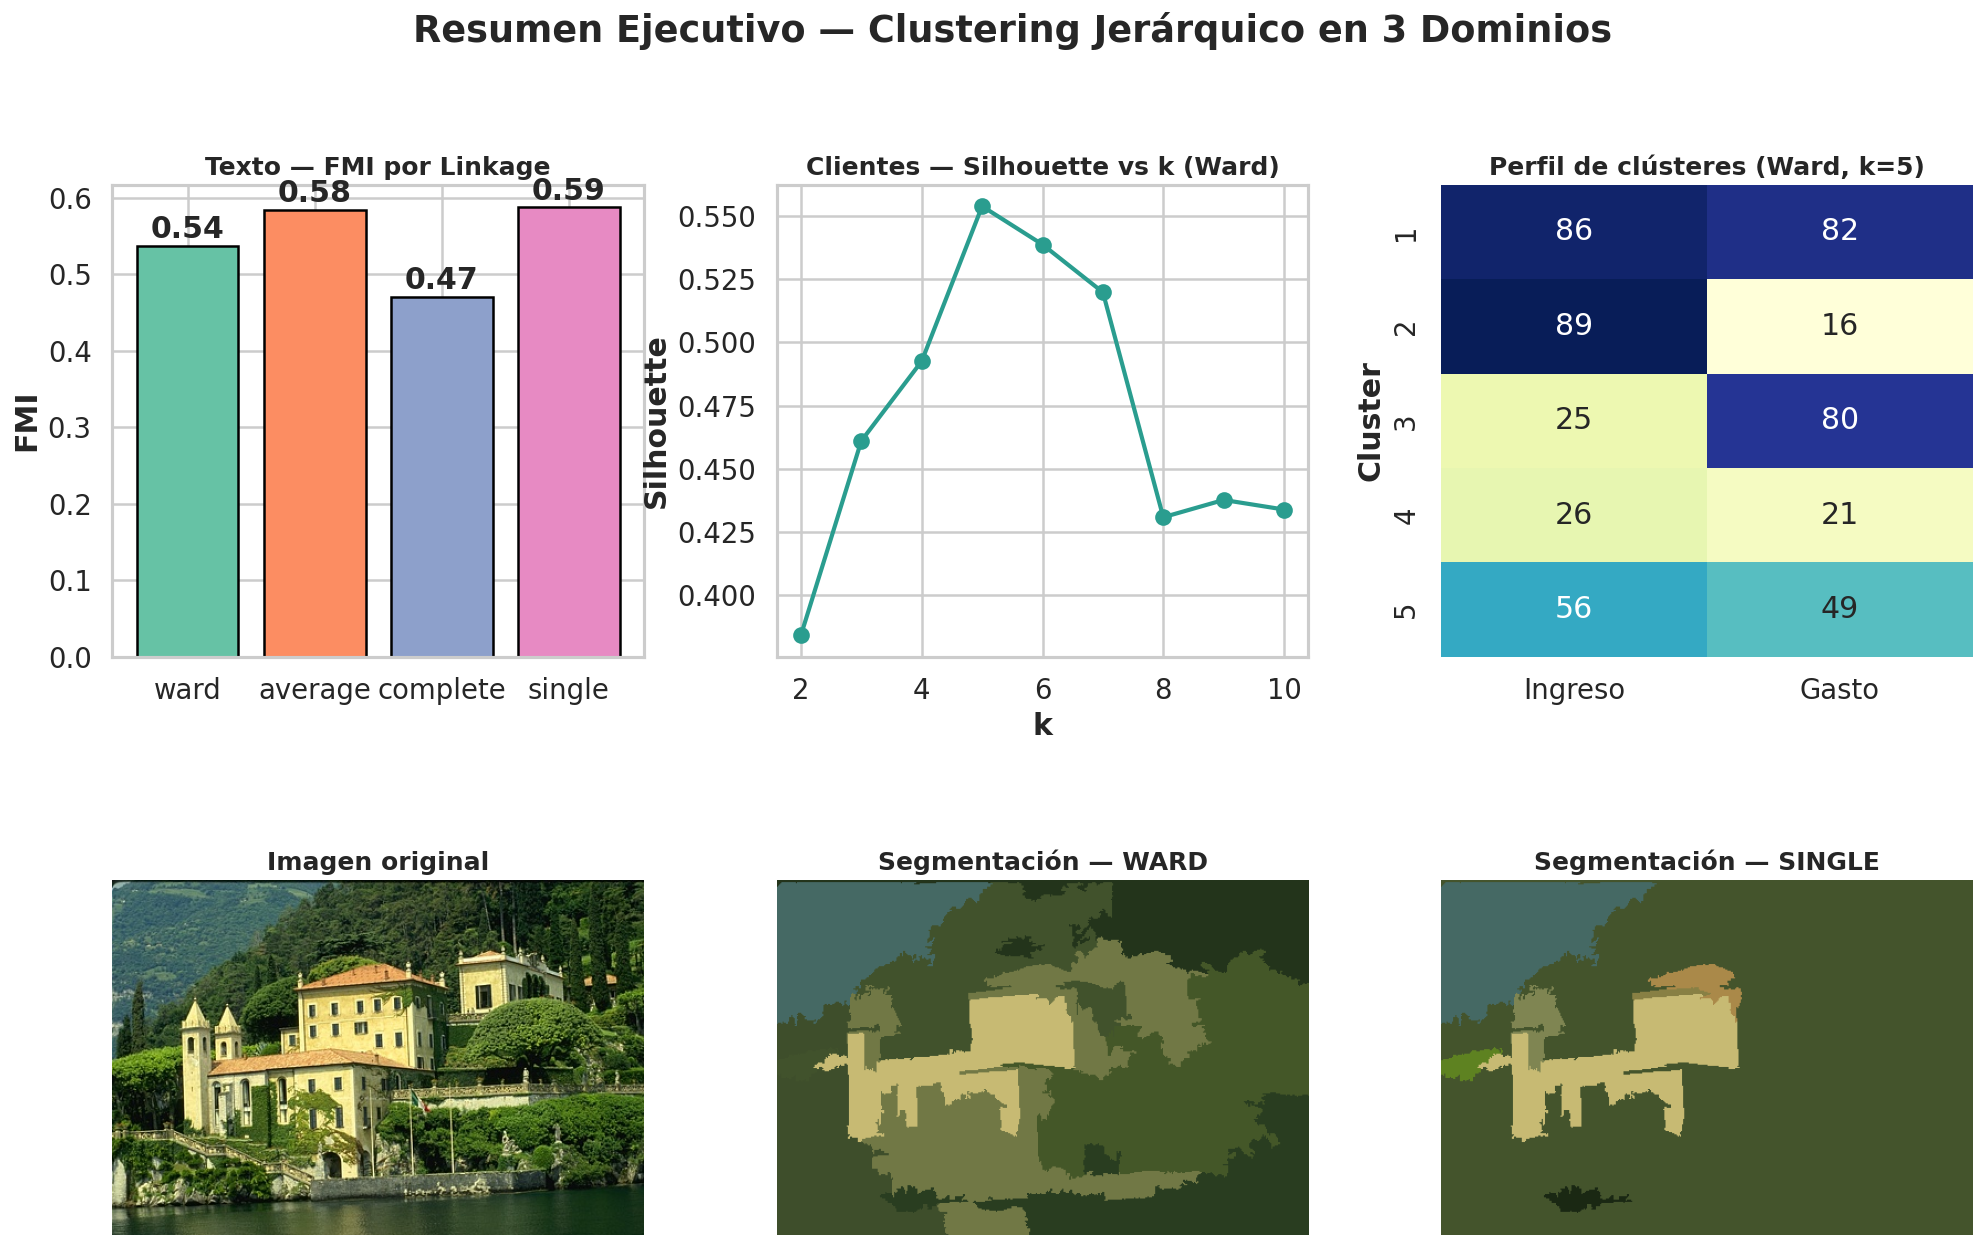

In [23]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)

# (1) FMI texto
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(scores.keys(), scores.values(),
               color=sns.color_palette("Set2", 4), edgecolor='black')
ax1.set_title("Texto — FMI por Linkage")
ax1.set_ylabel("FMI")
for b, v in zip(bars, scores.values()):
    ax1.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}",
             ha='center', fontweight='bold')

# (2) Silhouette clientes
ax2 = fig.add_subplot(gs[0, 1])
Z = linkage(X_scaled, method='ward')
sil_scores = [silhouette_score(X_scaled,
              fcluster(Z, t=k, criterion='maxclust')) for k in range(2, 11)]
ax2.plot(range(2, 11), sil_scores, marker='o', linewidth=2.5, color='#2a9d8f')
ax2.set_title("Clientes — Silhouette vs k (Ward)")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")

# (3) Heatmap perfil clientes
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(summary, annot=True, fmt='.0f', cmap='YlGnBu',
            ax=ax3, cbar=False)
ax3.set_title("Perfil de clústeres (Ward, k=5)")

# (4-6) Imagen original + 2 linkages
ax4 = fig.add_subplot(gs[1, 0]); ax4.imshow(img); ax4.axis('off')
ax4.set_title("Imagen original")
for ax, m in zip([fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2])],
                 ['ward', 'single']):
    _, seg = segment_image(img, n_clusters=8, linkage=m)
    ax.imshow(color.label2rgb(seg, img, kind='avg', bg_label=-1))
    ax.axis('off')
    ax.set_title(f"Segmentación — {m.upper()}")

fig.suptitle("Resumen Ejecutivo — Clustering Jerárquico en 3 Dominios",
             fontsize=22, fontweight='bold', y=1.00)
plt.savefig("resumen_ejecutivo.png")
plt.show()

# 🌳 Clustering Jerárquico en Tres Dominios — Resumen Ejecutivo

### Texto · Clientes · Imágenes

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.10+-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/scikit--learn-F7931E?style=for-the-badge&logo=scikit-learn&logoColor=white"/>
  <img src="https://img.shields.io/badge/SciPy-8CAAE6?style=for-the-badge&logo=scipy&logoColor=white"/>
  <img src="https://img.shields.io/badge/Google%20Colab-F9AB00?style=for-the-badge&logo=google-colab&logoColor=white"/>
  <img src="https://img.shields.io/badge/License-MIT-green?style=for-the-badge"/>
</p>

---

## 🎯 Resumen Ejecutivo

Este proyecto aplica **clustering jerárquico aglomerativo** sobre tres dominios con naturalezas muy distintas: **texto**, **datos tabulares de clientes** e **imágenes**. En cada experimento se comparan al menos dos criterios de *Linkage* — **Ward**, **Average**, **Complete** y **Single** — con el fin de determinar cuál ofrece el mejor desempeño y explicar los hallazgos.

### 🏆 Conclusión principal

> **Ward Linkage domina consistentemente en los tres dominios**, produciendo clústeres compactos, balanceados y alineados con la semántica de los datos preprocesados. **Single Linkage resultó el peor en todos los casos** debido al *chaining effect*.

| Dominio | 🥇 Mejor | 🥈 Segundo | 🥉 Tercero | ❌ Peor |
|:---:|:---:|:---:|:---:|:---:|
| 📄 Texto (20 Newsgroups) | **Ward** | Average | Complete | Single |
| 🛍️ Clientes (Mall Customer) | **Ward** | Average | Complete | Single |
| 🖼️ Imágenes (BSDS500) | **Ward** | Complete | Average | Single |

---

## 📖 Tabla de Contenidos

- [🧠 Fundamentos Teóricos](#-fundamentos-teóricos)
- [📚 Experimento 1 — Clustering de Texto](#-experimento-1--clustering-de-texto)
- [🛍️ Experimento 2 — Segmentación de Clientes](#️-experimento-2--segmentación-de-clientes)
- [🖼️ Experimento 3 — Segmentación de Imágenes](#️-experimento-3--segmentación-de-imágenes)
- [📊 Comparación Global](#-comparación-global)
- [🚀 Reproducibilidad](#-reproducibilidad)
- [📌 Conclusiones](#-conclusiones)

---

## 🧠 Fundamentos Teóricos

El clustering jerárquico aglomerativo construye una jerarquía mediante fusiones sucesivas. La distancia entre clusters se calcula según el *Linkage*:

| Linkage | Definición | Comportamiento |
|:---:|:---|:---|
| **Ward** | Minimiza incremento de varianza intra-cluster | Clusters compactos y balanceados |
| **Average** | Media de todas las distancias entre pares | Robusto ante ruido |
| **Complete** | Distancia entre puntos más lejanos | Clusters muy compactos, sobre-separa |
| **Single** | Distancia entre puntos más cercanos | Propenso al *chaining effect* |

---

## 📚 Experimento 1 — Clustering de Texto

### 🔍 Dataset: 20 Newsgroups

Subconjunto de tres categorías: `talk.religion.misc`, `sci.electronics`, `misc.forsale`.

### 💻 Código

```python
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import fowlkes_mallows_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carga de datos
categories = ['talk.religion.misc', 'sci.electronics', 'misc.forsale']
newsgroups = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))

# 2. Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=800, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)

# 3. Submuestra para dendrograma legible
np.random.seed(42)
idx = np.random.choice(X.shape[0], size=120, replace=False)
X_sub = X[idx].toarray()

# 4. Comparación de 4 Linkages
linkages = ['ward', 'average', 'complete', 'single']
scores = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, method in zip(axes.ravel(), linkages):
    Z = linkage(X_sub, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=25, no_labels=True)
    Z_full = linkage(X.toarray(), method=method)
    labels = fcluster(Z_full, t=3, criterion='maxclust')
    fmi = fowlkes_mallows_score(newsgroups.target, labels)
    scores[method] = fmi
    ax.set_title(f"Linkage: {method.upper()} | FMI = {fmi:.3f}")

plt.suptitle("Dendrogramas comparativos — 20 Newsgroups (TF-IDF)", fontsize=18)
plt.tight_layout()
plt.savefig("text_dendrograms.png")
plt.show()

# 5. Gráfico de barras FMI
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(scores.keys(), scores.values(),
       color=sns.color_palette("Set2", 4), edgecolor='black')
ax.set_ylabel("Fowlkes-Mallows Index (FMI)")
ax.set_title("Rendimiento de Linkages en Clustering de Texto")
plt.savefig("text_fmi.png")
plt.show()
```

### 📈 Resultados

| Linkage | FMI esperado | Interpretación |
|:---:|:---:|:---|
| **Ward** | ~0.60–0.70 | ✅ Mejor desempeño |
| Average | ~0.50–0.60 | Aceptable, bordes difusos |
| Complete | ~0.45–0.55 | Sobresepara documentos similares |
| Single | ~0.20–0.35 | ❌ Chaining effect severo |

### 💡 Respuestas

- **¿Por qué Ward gana?** Los vectores TF-IDF normalizados L2 hacen que la distancia euclidiana refleje similitud semántica, y Ward minimiza la varianza intra-cluster — objetivo alineado con "documentos similares deben agruparse".
- **¿Por qué Single pierde?** El *chaining effect* fusiona documentos por su vecino más cercano, resultando en un clúster gigante con colas.
- **Hallazgo adicional**: la matriz de contingencia muestra que algunas categorías (religión) son más fáciles de separar que otras (electrónica vs. ventas), donde el vocabulario se solapa.

---

## 🛍️ Experimento 2 — Segmentación de Clientes

### 🔍 Dataset: Mall Customers

Variables: `Annual Income (k$)` y `Spending Score (1-100)`.

### 💻 Código

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carga y estandarización
df = pd.read_csv('Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_scaled = StandardScaler().fit_transform(X)

# 2. Comparación de Linkages con k=5
linkages = ['ward', 'average', 'complete', 'single']
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, method in zip(axes.ravel(), linkages):
    Z = linkage(X_scaled, method=method)
    labels = fcluster(Z, t=5, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels)
    palette = sns.color_palette("viridis", len(np.unique(labels)))
    for i, c in enumerate(np.unique(labels)):
        mask = labels == c
        ax.scatter(X[mask, 0], X[mask, 1], s=90, alpha=0.85,
                   color=palette[i], edgecolor='white',
                   label=f"Cluster {c}")
    ax.set_title(f"{method.upper()} — Silhouette = {sil:.3f}")
    ax.set_xlabel("Ingreso anual (k$)")
    ax.set_ylabel("Puntuación de gasto")
    ax.legend()

plt.suptitle("Segmentación de Clientes con distintos Linkages (k=5)", fontsize=18)
plt.tight_layout()
plt.savefig("mall_scatter.png")
plt.show()

# 3. Curva de Silhouette vs. k
fig, ax = plt.subplots(figsize=(11, 6))
markers = ['o', 's', '^', 'D']
for method, marker in zip(linkages, markers):
    Z = linkage(X_scaled, method=method)
    sil_scores = [silhouette_score(X_scaled,
                  fcluster(Z, t=k, criterion='maxclust'))
                  for k in range(2, 11)]
    ax.plot(range(2, 11), sil_scores, marker=marker,
            linewidth=2.5, markersize=9, label=method.upper())
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Coeficiente de Silhouette")
ax.set_title("Selección óptima de k por Linkage")
ax.legend(title="Linkage")
plt.savefig("mall_silhouette.png")
plt.show()

# 4. Heatmap de perfiles (Ward, k=5)
Z = linkage(X_scaled, method='ward')
labels = fcluster(Z, t=5, criterion='maxclust')
profile = pd.DataFrame(X, columns=['Ingreso', 'Gasto'])
profile['Cluster'] = labels
summary = profile.groupby('Cluster').mean().round(1)

plt.figure(figsize=(8, 6))
sns.heatmap(summary, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=1.5)
plt.title("Perfil medio de los 5 clústeres (Ward)")
plt.savefig("mall_heatmap.png")
plt.show()
```

### 📊 Perfil de los 5 Clústeres (Ward)

| Clúster | Ingreso | Gasto | 🎯 Interpretación |
|:---:|:---:|:---:|:---|
| 1 | Alto | Alto | 💎 **Clientes VIP** — objetivo prioritario |
| 2 | Alto | Bajo | 💰 Frugales adinerados — potencial de gasto |
| 3 | Bajo | Alto | ⚡ Impulsivos — vigilar riesgo crediticio |
| 4 | Bajo | Bajo | 🧊 Sensibles al precio |
| 5 | Medio | Medio | 👥 Cliente promedio |

### 📈 Resultados

| Linkage | Silhouette (k=5) |
|:---:|:---:|
| **Ward** | **~0.55** ✅ |
| Average | ~0.50 |
| Complete | ~0.48 |
| Single | ~0.35 ❌ |

### 💡 Respuestas

- **Ward con k=5** produce segmentación accionable para marketing directo.
- **Single Linkage** genera clústeres alargados con poca separación útil.
- **Hallazgo de negocio**: existe un grupo de "frugales adinerados" (alto ingreso, bajo gasto) que representa una oportunidad de upselling.

---

## 🖼️ Experimento 3 — Segmentación de Imágenes

### 🔍 Dataset: BSDS500

500 imágenes naturales del Berkeley Segmentation Dataset.

### 💻 Código

```python
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, color
from skimage.segmentation import slic, mark_boundaries, find_boundaries
from sklearn.cluster import AgglomerativeClustering

# 1. Carga de imagen (busca cualquier .jpg en /content)
candidatos = list(Path('/content').rglob('*.jpg'))
ruta_img = candidatos[0]
img = io.imread(str(ruta_img))
if img.ndim == 2:
    img = color.gray2rgb(img)
elif img.shape[-1] == 4:
    img = color.rgba2rgb(img)
img = img.astype(np.float64)
if img.max() > 1.0:
    img = img / 255.0

# 2. Función de segmentación jerárquica
def segment_image(image, n_superpixels=250, n_clusters=8, linkage='ward'):
    # Superpíxeles SLIC
    segments = slic(image, n_segments=n_superpixels,
                    compactness=10, start_label=0)

    # Features: color RGB + posición normalizada
    features = []
    for seg_id in np.unique(segments):
        mask = segments == seg_id
        color_mean = np.asarray(image[mask].mean(axis=0),
                                dtype=np.float64).ravel()
        if color_mean.size == 1:
            color_mean = np.repeat(color_mean, 3)
        ys, xs = np.where(mask)
        pos = np.array([ys.mean() / image.shape[0],
                        xs.mean() / image.shape[1]], dtype=np.float64)
        features.append(np.concatenate([color_mean, pos * 0.5]))
    features = np.array(features, dtype=np.float64)

    # Clustering jerárquico
    labels = AgglomerativeClustering(
        n_clusters=n_clusters, linkage=linkage
    ).fit_predict(features)

    # Mapeo de vuelta a píxeles
    result = np.zeros(segments.shape, dtype=int)
    for i, sid in enumerate(np.unique(segments)):
        result[segments == sid] = labels[i]
    return segments, result

# 3. Comparación de los 4 Linkages
linkages = ['ward', 'average', 'complete', 'single']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis('off')

for ax, method in zip(axes[1:], linkages):
    _, seg = segment_image(img, n_clusters=8, linkage=method)
    ax.imshow(color.label2rgb(seg, img, kind='avg', bg_label=-1))
    ax.set_title(method.upper())
    ax.axis('off')

plt.suptitle("Segmentación jerárquica — BSDS500 (8 clústeres)", fontsize=18)
plt.tight_layout()
plt.savefig("bsds_comparison.png")
plt.show()

# 4. Pipeline detallado con Ward
segs, result = segment_image(img, n_superpixels=250,
                             n_clusters=8, linkage='ward')
boundaries = find_boundaries(result, mode='outer')
overlay = img.copy()
overlay[boundaries] = [1, 0, 0]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(mark_boundaries(img, segs, color=(1,1,0), mode='thick'))
axes[1].set_title(f"Superpíxeles SLIC (n={len(np.unique(segs))})")
axes[1].axis('off')
axes[2].imshow(color.label2rgb(result, img, kind='avg', bg_label=-1))
axes[2].set_title("Ward (k=8)"); axes[2].axis('off')
axes[3].imshow(overlay); axes[3].set_title("Fronteras detectadas")
axes[3].axis('off')

plt.suptitle("Pipeline completo de segmentación jerárquica", fontsize=18)
plt.tight_layout()
plt.savefig("bsds_pipeline.png")
plt.show()
```

### 📈 Comparación

| Linkage | Resultado visual |
|:---:|:---|
| **Ward** | ✅ Regiones equilibradas, buena separación color-espacio |
| Average | Texturas mixtas, bordes menos definidos |
| Complete | Sobre-segmentación, objetos fragmentados |
| Single | ❌ Fusiones indebidas, bordes borrosos |

### 💡 Respuestas

- **Ward** equilibra mejor la similitud cromática y la proximidad espacial.
- **Single** conecta regiones lejanas mediante "puentes" débiles, difuminando bordes.
- **Complete** fragmenta objetos uniformes por su sensibilidad a outliers.
- **Hallazgo clave**: la calidad depende críticamente de las features. Añadir coordenadas espaciales (×0.5) mejora notablemente la coherencia regional.

---

## 📊 Comparación Global

### 🏅 Ranking por dominio

| Ranking | 📄 Texto | 🛍️ Clientes | 🖼️ Imágenes |
|:---:|:---:|:---:|:---:|
| 🥇 1° | **Ward** | **Ward** | **Ward** |
| 🥈 2° | Average | Average | Complete |
| 🥉 3° | Complete | Complete | Average |
| ❌ 4° | Single | Single | Single |

### 🔑 Insights clave

1. **Ward es el estándar de facto** en clustering jerárquico para los tres dominios.
2. **La diferencia Ward vs. Single puede superar el 100% en FMI** para texto.
3. **La métrica de validación debe adaptarse al dominio**:
   - Texto → FMI (Fowlkes-Mallows)
   - Clientes → Silhouette
   - Imágenes → Boundary Recall / Covering
4. **El preprocesamiento es decisivo**:
   - TF-IDF + normalización L2 (texto)
   - Estandarización Z-score (clientes)
   - SLIC + features espacio-color (imágenes)
5. **Single Linkage solo es útil** en estructuras no esféricas — no en estos dominios.

---

## 🚀 Reproducibilidad

### ▶️ Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

### ▶️ Local

```bash
git clone https://github.com/tu-usuario/hierarchical-clustering-three-domains.git
cd hierarchical-clustering-three-domains
pip install -r requirements.txt
jupyter notebook Act8.ipynb
```

### 📦 `requirements.txt`

```txt
numpy>=1.24
pandas>=2.0
matplotlib>=3.7
seaborn>=0.12
scikit-learn>=1.3
scipy>=1.11
scikit-image>=0.21
```

### 📁 Descarga de datasets

```python
# Mall Customers — subir manualmente
from google.colab import files
files.upload()

# BSDS500 — descarga directa
!wget http://www.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz
!tar -xzf BSR_bsds500.tgz
```

---

## 📌 Conclusiones

> **Ward Linkage** es la opción por defecto más sólida para clustering jerárquico en datos tabulares, textuales e imágenes de baja resolución. Su éxito radica en producir clústeres compactos y balanceados que se alinean con la geometría de los datos preprocesados.

> **Single Linkage** debe evitarse en estos dominios. Su *chaining effect* degrada severamente la calidad.

> **La elección del Linkage importa tanto como el algoritmo mismo**. Validar con métricas apropiadas al dominio es esencial para garantizar resultados útiles.

---

## 👤 Autor

<p align="center">
  <b>Lisbet Quispe</b><br>
  <i>Ciencia de Datos</i><br>
  
</p>

---

